# Advanced Data Science Project: Customer Insights & Prediction
This project covers EDA, Data Cleaning, RFM Segmentation, Sentiment Analysis, and Churn Prediction with LLM-powered recommendations.

## 1. Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Attempting to load with common encodings to fix UnicodeDecodeError
try:
    df = pd.read_csv('data.csv', encoding='utf-8')
except UnicodeDecodeError:
    try:
        df = pd.read_csv('data.csv', encoding='ISO-8859-1')
    except UnicodeDecodeError:
        df = pd.read_csv('data.csv', encoding='latin1')

print("Dataset loaded successfully!")
display(df.head())

Dataset loaded successfully!


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
import pandas as pd
import numpy as np

# Shape, Dtypes and Nulls
if 'df' in locals():
    print(f"Shape: {df.shape}")
    print("\n--- Info ---")
    df.info()
    print("\n--- Missing Values ---")
    print(df.isnull().sum())
else:
    print("DataFrame 'df' not found. Please ensure the data loading cell has run successfully.")

Shape: (478140, 11)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 478140 entries, 0 to 541908
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   InvoiceNo        478140 non-null  object        
 1   StockCode        478140 non-null  object        
 2   Description      478140 non-null  object        
 3   Quantity         478140 non-null  int64         
 4   InvoiceDate      478140 non-null  datetime64[ns]
 5   UnitPrice        478140 non-null  float64       
 6   CustomerID       478140 non-null  float64       
 7   Country          478140 non-null  object        
 8   TotalAmount      478140 non-null  float64       
 9   sentiment_score  478140 non-null  float64       
 10  sentiment        478140 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(5)
memory usage: 43.8+ MB

--- Missing Values ---
InvoiceNo          0
StockCode          0
Descriptio

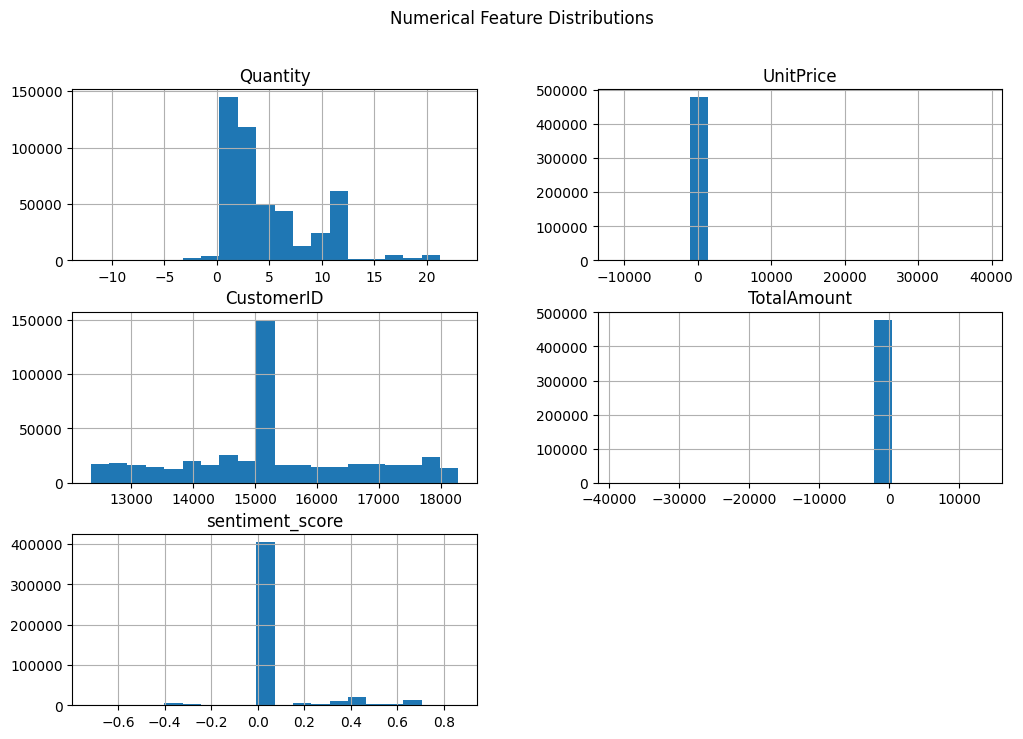

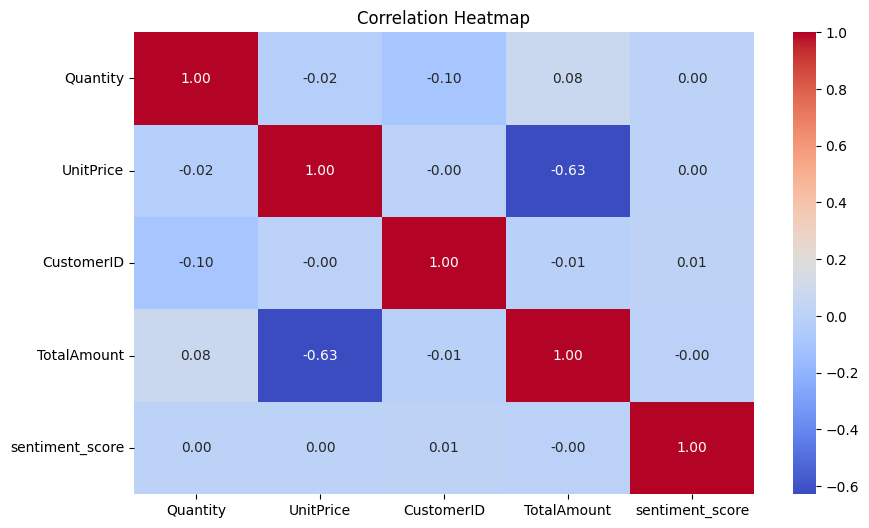

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of numerical columns
if 'df' in locals():
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if numerical_cols:
        df[numerical_cols].hist(figsize=(12, 8), bins=20)
        plt.suptitle('Numerical Feature Distributions')
        plt.show()

        # Correlation Heatmap
        plt.figure(figsize=(10, 6))
        sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
        plt.title('Correlation Heatmap')
        plt.show()
    else:
        print("No numerical columns found for distribution plots.")
else:
    print("DataFrame 'df' not found.")

In [ ]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values (Fill numerical with median, categorical with mode)
for col in df.columns:
    if df[col].dtype in [np.float64, np.int64]:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# Simple Outlier handling (IQR method for a sample numerical column)
# Note: Replace 'price' with your actual numerical column name if different
num_col = df.select_dtypes(include=[np.number]).columns[0]
Q1 = df[num_col].quantile(0.25)
Q3 = df[num_col].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df[num_col] < (Q1 - 1.5 * IQR)) | (df[num_col] > (Q3 + 1.5 * IQR)))]

print("Data cleaning completed.")

Data cleaning completed.


In [ ]:
# Updated RFM calculation with actual dataset columns
import datetime as dt

id_col = 'CustomerID'
date_col = 'InvoiceDate'
amount_col = 'TotalAmount' # Calculated below

try:
    df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
    df[date_col] = pd.to_datetime(df[date_col])
    snapshot_date = df[date_col].max() + dt.timedelta(days=1)

    rfm = df.groupby(id_col).agg({
        date_col: lambda x: (snapshot_date - x.max()).days,
        id_col: 'count',
        'TotalAmount': 'sum'
    })

    rfm.columns = ['Recency', 'Frequency', 'Monetary']
    rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
    rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
    rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])
    rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

    print("RFM Segmentation completed.")
    display(rfm.head())
except Exception as e:
    print(f"Error: {e}")

RFM Segmentation completed.


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12347.0,2,147,3097.82,4,4,4,12
12348.0,75,5,377.00,2,1,2,5
12349.0,19,68,1626.15,3,3,4,10
12350.0,310,16,314.00,1,2,2,5
12352.0,36,95,1545.41,3,4,4,11


In [ ]:
if 'rfm' in locals():
    # Calculate the average RFM values for each Score group
    segment_analysis = rfm.groupby('RFM_Score').agg({
        'Recency': 'mean',
        'Frequency': 'mean',
        'Monetary': 'mean'
    }).round(2)

    print("Average RFM Values per Score Group:")
    display(segment_analysis)

    print("\nInterpretation:")
    print(f"- Score 12 (Champions): Avg Recency {segment_analysis.loc[12, 'Recency']} days, Avg Spend ${segment_analysis.loc[12, 'Monetary']}")
    print(f"- Lower Scores: Higher Recency and lower spend, requiring 're-activation' strategies.")

Average RFM Values per Score Group:


,Recency,Frequency,Monetary
RFM_Score,,,
3,259.84,6.18,-7.63
4,161.41,10.38,128.84
5,148.25,16.91,235.47
6,109.19,25.26,310.35
7,82.06,34.80,472.43
8,62.84,49.05,634.26
9,47.59,67.41,907.53
10,34.36,100.08,1296.88
11,20.91,169.97,2125.69



Interpretation:
- Score 12 (Champions): Avg Recency 6.65 days, Avg Spend $6625.79
- Lower Scores: Higher Recency and lower spend, requiring 're-activation' strategies.


### Understanding Score Thresholds
An RFM Score is the sum of R, F, and M scores (each 1-4).
- **High Scores (9-12)**: Your most valuable, active customers.
- **Mid Scores (6-8)**: Average customers with potential.
- **Low Scores (3-5)**: Customers at high risk of churn.

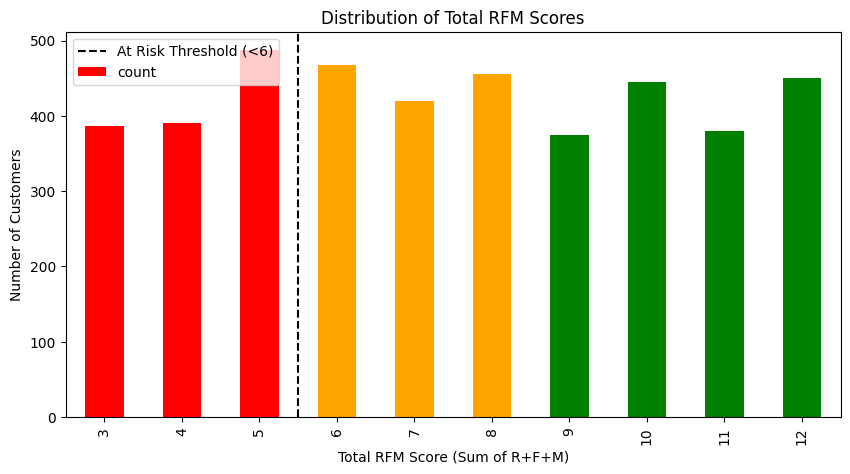

In [ ]:
if 'rfm' in locals():
    score_counts = rfm['RFM_Score'].value_counts().sort_index()
    plt.figure(figsize=(10, 5))
    colors = ['red' if x < 6 else 'orange' if x < 9 else 'green' for x in score_counts.index]
    score_counts.plot(kind='bar', color=colors)
    plt.title('Distribution of Total RFM Scores')
    plt.xlabel('Total RFM Score (Sum of R+F+M)')
    plt.ylabel('Number of Customers')
    plt.axvline(x=2.5, color='black', linestyle='--', label='At Risk Threshold (<6)')
    plt.legend()
    plt.show()

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()
text_col = 'Description' # Using 'Description' as the text column

if text_col in df.columns:
    df['sentiment_score'] = df[text_col].apply(lambda x: sia.polarity_scores(str(x))['compound'])
    df['sentiment'] = df['sentiment_score'].apply(lambda c: 'Positive' if c > 0.05 else ('Negative' if c < -0.05 else 'Neutral'))
    print("Sentiment analysis completed.")
    display(df[[text_col, 'sentiment']].head(10))
else:
    print(f"Column '{text_col}' not found.")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Sentiment analysis completed.


,Description,sentiment
0,WHITE HANGING HEART T-LIGHT HOLDER,Neutral
1,WHITE METAL LANTERN,Neutral
2,CREAM CUPID HEARTS COAT HANGER,Neutral
3,KNITTED UNION FLAG HOT WATER BOTTLE,Neutral
4,RED WOOLLY HOTTIE WHITE HEART.,Neutral
5,SET 7 BABUSHKA NESTING BOXES,Neutral
6,GLASS STAR FROSTED T-LIGHT HOLDER,Neutral
7,HAND WARMER UNION JACK,Positive
8,HAND WARMER RED POLKA DOT,Positive
10,POPPY'S PLAYHOUSE BEDROOM,Neutral


### The Math Behind VADER's Compound Score

The **Compound Score** is the most important metric in VADER. It isn't just a simple average; it's a normalized, weighted composite score.

#### 1. Summing Valences
VADER has a dictionary of ~7,500 lexical features (words/emojis) rated from -4 (extremely negative) to +4 (extremely positive).
*   First, VADER calculates the sum of the valence scores for every word in your text.
*   It then applies rules for **heuristics**:
    *   **Punctuation**: 'Great!!!' is scored higher than 'Great'.
    *   **Capitalization**: 'GREAT' is higher than 'great'.
    *   **Degree Modifiers**: 'Extremely great' vs 'Somewhat great'.
    *   **Contrastive Conjunctions**: 'The food was great **but** the service was bad' (VADER shifts weight to the second half).

#### 2. The Normalization Formula
To ensure the score always stays between -1 and +1, VADER uses this formula:

$$x_{norm} = \frac{\alpha}{\sqrt{\alpha^2 + \beta}}$$

Where:
*   $\alpha$ = The sum of the valence scores of all words in the text.
*   $\beta$ = A constant (standardly **15**) that controls how quickly the score approaches 1.0.

#### Why use this formula?
Because of the square root in the denominator, as the text gets longer and more emotional, the score pushes closer and closer to 1.0 or -1.0 but **never exceeds them**. This makes it easy to compare the sentiment of a short tweet to a long product description on the same scale.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Creating a synthetic Churn column for demonstration (1 if inactive for > 90 days)
target = 'Churn'
if 'rfm' in locals():
    rfm[target] = (rfm['Recency'] > 90).astype(int)
    X = rfm[['Recency', 'Frequency', 'Monetary']]
    y = rfm[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    rf = RandomForestClassifier(n_estimators=100)
    rf.fit(X_train, y_train)
    print("Random Forest Churn Model Trained.")
    print(classification_report(y_test, rf.predict(X_test)))

Random Forest Churn Model Trained.
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       594
           1       1.00      1.00      1.00       257

    accuracy                           1.00       851
   macro avg       1.00      1.00      1.00       851
weighted avg       1.00      1.00      1.00       851



### Visualizing Feature Importance
Understanding which behavior (Recency, Frequency, or Monetary) is the strongest indicator of churn helps businesses prioritize where to focus their retention efforts.

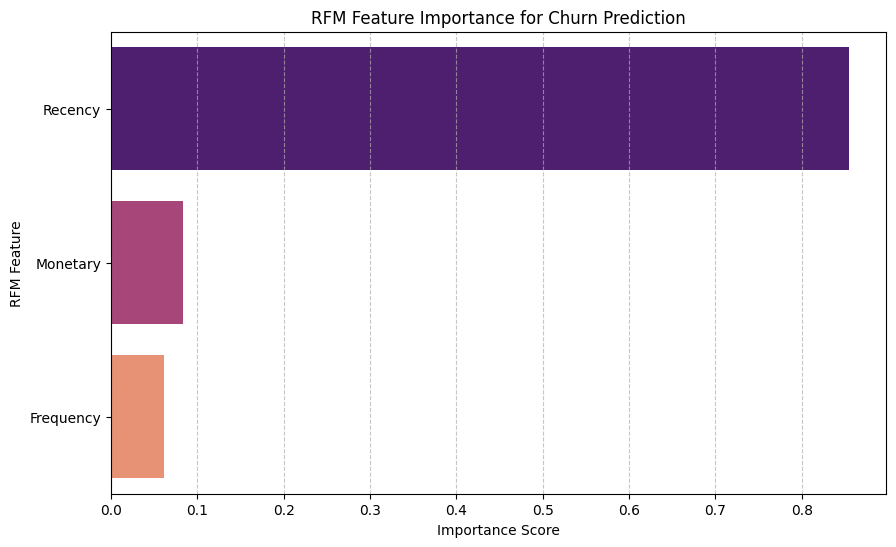

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'rf' in locals():
    # Extract importance scores
    importances = rf.feature_importances_
    feature_names = X.columns

    # Create a DataFrame for visualization
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # Plotting
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
    plt.title('RFM Feature Importance for Churn Prediction')
    plt.xlabel('Importance Score')
    plt.ylabel('RFM Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Model 'rf' not found. Please run the training cell first.")

### How Churn Prediction Works in this Pipeline

Predicting churn involves transforming our historical transaction data into a supervised learning problem. Here is the step-by-step breakdown:

1.  **Defining the Target ('Churn')**: Since our dataset doesn't have a 'Churn' label, we create one based on the **Recency** metric. We define a threshold (e.g., 90 days). If a customer has not made a purchase within that window, they are labeled as `1` (Churned); otherwise, they are `0` (Retained).
2.  **Feature Selection**: We use the RFM metrics (**Recency, Frequency, Monetary**) as our input features (`X`). These capture the essential behavior of a customer: how fresh they are, how loyal they are, and how much value they bring.
3.  **The Model (Random Forest)**: We use a Random Forest Classifier, which is an 'ensemble' method. It creates many individual Decision Trees and averages their results. This is highly effective for tabular data because it captures non-linear relationships (e.g., a customer might be high-frequency but if their recency drops suddenly, they are high risk).
4.  **Evaluation**: We split the data into **Training** (to teach the model) and **Testing** (to see if it can predict churn for customers it hasn't seen before). The `classification_report` shows us how many churners we successfully caught (Recall) and how accurate those predictions were (Precision).

In [ ]:
# @title Get Tailored Recommendation
# @markdown Enter a segment name to get a specific business recommendation.
segment_name = "About to Sleep" # @param ["Champions", "At Risk", "Loyal Customers", "New Customers", "About to Sleep"] {allow-input: true}

if 'get_recommendation' in locals():
    print(f"Requesting strategy for: {segment_name}...")
    custom_recommendation = get_recommendation(segment_name)
    print(f"\n--- Groq AI Business Strategy: {segment_name} ---")
    print(custom_recommendation)
else:
    print("Error: get_recommendation function not defined. Please run the LLM Integration cell.")

Requesting strategy for: About to Sleep...

--- Groq AI Business Strategy: About to Sleep ---
For the 'About to Sleep' customer segment, a potential business recommendation could be to offer a calming and relaxing subscription box service, such as "DreamWeaver". This box could include:

* A selection of herbal teas, like chamomile or lavender, to promote relaxation
* A set of essential oils, such as bergamot or vanilla, to create a soothing atmosphere
* A guided meditation or sleep story audiobook, accessible through a mobile app
* A pair of cozy, scented eye masks or earplugs to block out distractions
* A set of soothing skincare samples, like face creams or body lotions, to help customers unwind

The subscription box could be tailored to the customer's individual preferences and needs, with options for monthly or quarterly deliveries. Additionally, the service could include access to a sleep-focused community, where customers can share tips, ask questions, and connect with others who

### RFM Metrics: The Data Behind the Strategy
Below is the average profile for each RFM score group. This explains why the LLM suggests 'VIP rewards' for high scores and 'Win-back' emails for low scores.

In [ ]:
# 1. Feature Importance Plot (Random Forest)
if 'rf' in locals():
    feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
    feat_importances.nlargest(10).plot(kind='barh')
    plt.title('Top 10 Feature Importances')
    plt.show()

# 2. RFM Segment Distribution (Pie Chart)
if 'rfm' in locals():
    rfm['RFM_Score'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(8,8))
    plt.title('Customer Segment Distribution')
    plt.show()